In [1]:
from pathlib import Path

import pandas as pd
from matplotlib import pyplot as plt
from vascx.utils.fundus import FundusPreprocessor
from vascx.utils.data_loading import load_image
from vascx.utils.mask_extraction import extract_bounds
from vascx.models.run import preprocess_for_inference

## Preprocessing

This code will preprocess the images and write .npy files with the square fundus image and the contrast enhanced version

This step is not strictly necessary, but it is useful if you want to run the preprocessing step separately before model inference

In [2]:
ds_path = Path("../samples/ergo/good/rgb")

In [3]:
files = list(ds_path.glob("*.png"))

In [4]:
bounds = preprocess_for_inference(files, rgb_path="../samples/ergo/good/preprocessed_rgb", npy_path="../samples/ergo/good/preprocessed_npy")
df_bounds = pd.DataFrame(bounds).set_index("id")
df_bounds.index = df_bounds.index.map(int)

0it [00:00, ?it/s][Parallel(n_jobs=-1)]: Using backend LokyBackend with 24 concurrent workers.
16it [00:00, 1136.05it/s]
[Parallel(n_jobs=-1)]: Done   3 out of  16 | elapsed:    7.4s remaining:   32.1s
[Parallel(n_jobs=-1)]: Done   5 out of  16 | elapsed:    8.1s remaining:   17.9s
[Parallel(n_jobs=-1)]: Done   7 out of  16 | elapsed:    8.8s remaining:   11.3s
[Parallel(n_jobs=-1)]: Done   9 out of  16 | elapsed:    9.0s remaining:    7.0s
[Parallel(n_jobs=-1)]: Done  11 out of  16 | elapsed:    9.9s remaining:    4.5s
[Parallel(n_jobs=-1)]: Done  13 out of  16 | elapsed:   10.1s remaining:    2.3s
[Parallel(n_jobs=-1)]: Done  16 out of  16 | elapsed:   10.8s finished


In [5]:
# df_bounds contains the bounds of each image (circle and rectangle)
# this information can be used to "reconstruct" the original fundus 
# or to transform model output to make it match the original image
df_bounds.to_csv("../samples/ergo/good/meta.csv")

In [6]:
# note: ERGO-only. Ignore if you don't have a meta.csv file
# meta = pd.read_csv("../samples/ergo/good/meta.csv", index_col="id").drop(
#     ["orig", "padding", "pos", "Unnamed: 0"], axis=1
# )
# df = pd.merge(meta, df_bounds, on="id", how="left")
# df.to_csv("../samples/ergo/good/meta.csv")

## FundusPreprocessor

Here we use the fundus preprocessor directly to preprocess and plot a single image

In [7]:
im_path = "../samples/ergo/good/rgb/318392.png"

In [8]:
prep_function = FundusPreprocessor(
    square_size=1024,
    contrast_enhance=True,
)

In [9]:
im_orig = load_image(im_path)

In [10]:
(im, ce), tg, bounds = prep_function(im_orig)

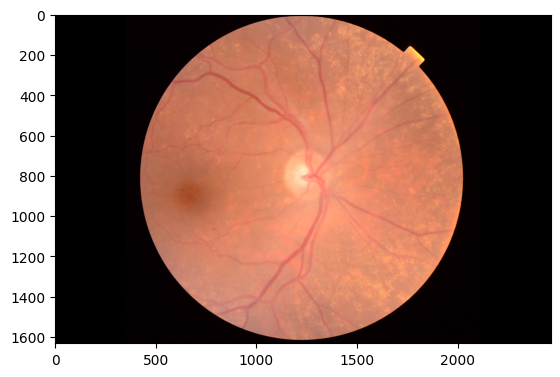

In [11]:
plt.imshow(im_orig)

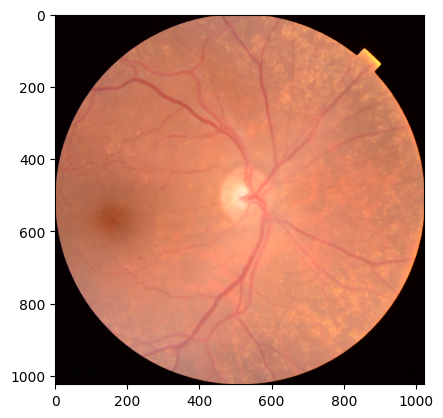

In [12]:
plt.imshow(im)

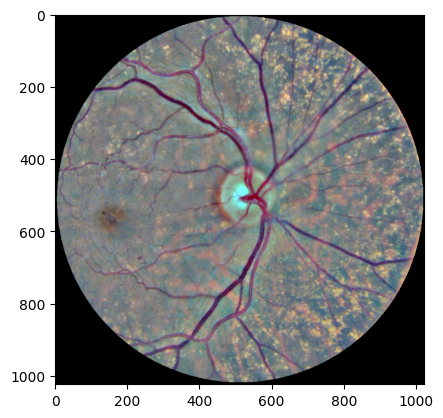

In [13]:
plt.imshow(ce)

In [14]:
import numpy as np

In [37]:
im = np.load("/mnt/oogergo/eyened/jose_files/replication/npy/607152.npy")

In [38]:
im.shape

(1024, 1024, 6)

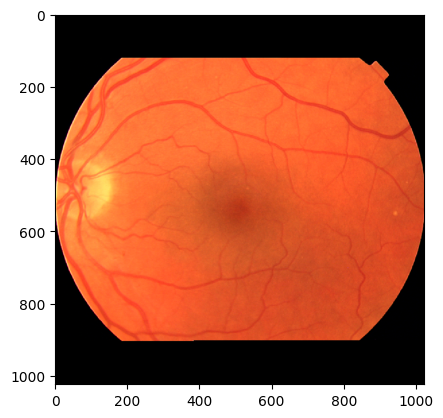

In [39]:
plt.imshow(im[...,:3])

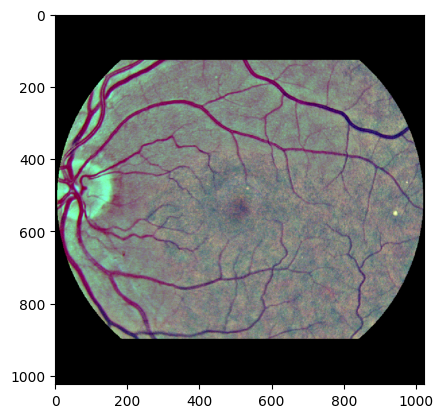

In [40]:
plt.imshow(im[..., 3:])